In [21]:
"""

1. 加载数据
2. 建立模型
3. 训练模型
4. 预测和评估模型
5. 保存和加载模型
6. 整合内容

"""
import torch
from torch import nn # nn 包含了 Pytorch 构建神经网络的所有模块
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用于正常显示负号

torch.__version__

'2.9.0+cu126'

# 1. 数据准备和加载

在机器学习中，数据可以是任何东西

* Excel表格
* 任何类型的图片
* 视频
* 音频
* DNA
* 文本

机器学习是由两部分组成的过程：
1. 将数据转换成数值表示
2. 构建模型来学习其中模式

In [22]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X =  torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [23]:
len(X), len(y)

(50, 50)

## 划分数据集

In [24]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [25]:
len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

In [26]:
def plot_predictions(
        train_data = X_train,
        train_labels = y_train,
        test_data = X_test,
        test_labels = y_test,
        predictions = None

):
    """
    绘制训练集和测试集的数据

    :param train_data:
    :param train_labels:
    :param test_data:
    :param test_labels:
    :param predictions:
    :return:
    """
    plt.figure(figsize=(10,7))

    # 绘制训练集数据用蓝色表示
    plt.scatter(train_data, train_labels, c="b", s=4, label="训练集数据")


    # 绘制训练集数据用绿色表示
    plt.scatter(test_data, test_labels, c="g", s=4, label="测试集数据")

    # 是否有预测数据
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="预测结果")

    plt.legend(prop={"size":14})



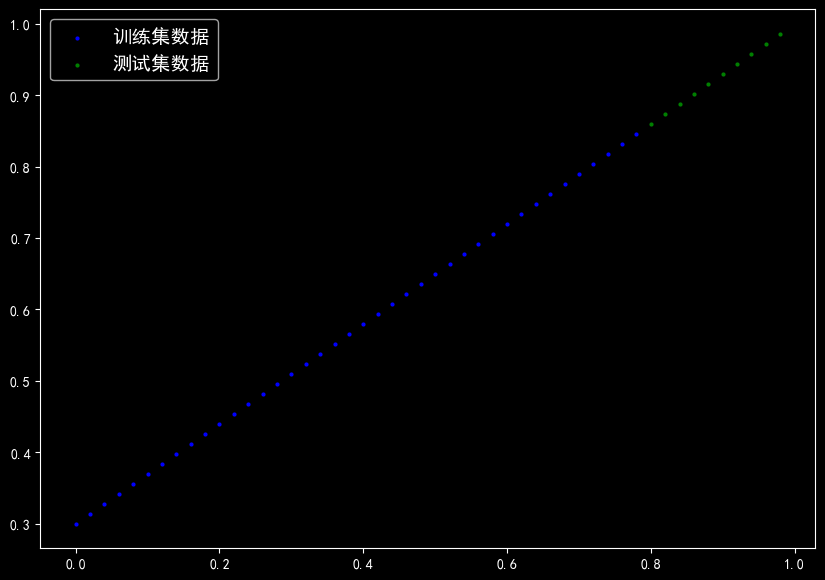

In [27]:
plot_predictions()

## 2. 建立模型

In [28]:
# 创建线性回归分类模型
from torch import nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))

        self.bias = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
        # 前向传播
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [29]:
# 创建随机种子
torch.manual_seed(42)

# 创建一个模型的instance
model_linear = LinearRegressionModel()

list(model_linear.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

我们也可以用 .state_dict() 得到模型的状态（模型包含什么）。

In [30]:
model_linear.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [31]:
X_test

tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

In [34]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

In [33]:
with torch.inference_mode():
    y_preds = model_linear(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

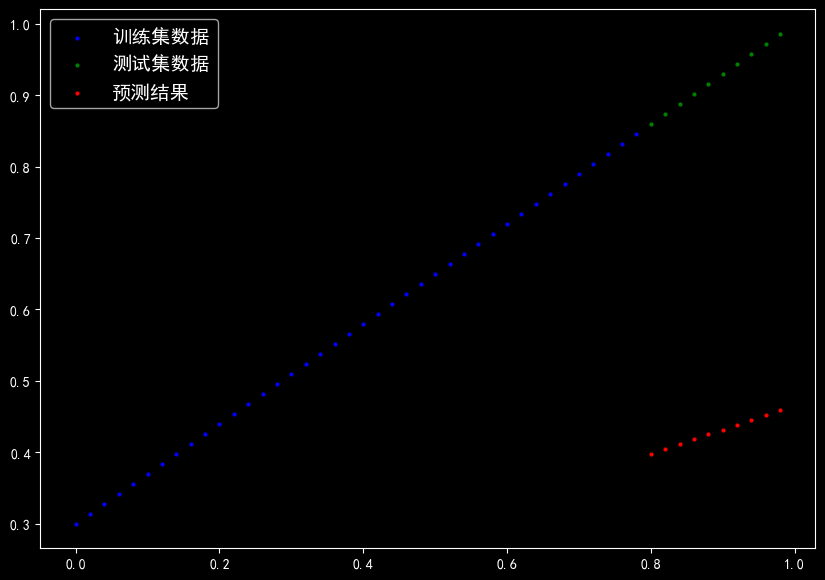

In [35]:
plot_predictions(predictions=y_preds)

## PyTorch model building essentials
## PyTorch 模型构建必备


PyTorch 有四个（或多或少）基本模块，你可以用来创建几乎任何你能想象的神经网络。

它们分别是 `torch.nn` 、 `torch.optim` 和 `torch.utils.data.Dataset` `torch.utils.data.DataLoader`。现在我们先聚焦前两者，后面再讲另外两者（不过你或许能猜到它们的作用）。

PyTorch module   |	它有什么作用
---|---
`torch.nn`	|包含计算图的所有构建模块（本质上是以特定方式执行的一系列计算）。
`torch.nn.Parameter`	|存储可与 交互的 nn.Module 张量。如果 requires_grad=True 梯度（用于通过梯度下降更新模型参数）是自动计算的，通常称为“自坡度”。
`torch.nn.Module`	|所有神经网络模块的基类，所有神经网络的构建模块都是子类。如果你在 PyTorch 中构建神经网络，你的模型应该子类 nn.Module 。需要实现一种 forward() 方法。
`torch.optim`	|包含多种优化算法（这些算法告诉存储的 nn.Parameter 模型参数如何最佳调整以改善梯度下降，从而减少损失）。
`def forward()`	| 所有 nn.Module 子类都需要一个 forward() 方法，该方法定义了对传递给特定 nn.Module 数据的计算（例如上述线性回归公式）。

如果上述内容听起来复杂，可以这样想，PyTorch 神经网络中的几乎所有内容都来自 `torch.nn` ，


- `nn.Module` 包含较大的构建单元（层）

- `nn.Parameter` 包含权重和偏差等较小参数（将它们组合起来形成 nn.Module （s））

- `forward()` 告诉较大的块如何对（s）内 nn.Module 输入（充满数据的张量）进行计算

- `torch.optim`包含如何改进参数 nn.Parameter 以更好地表示输入数据的优化方法

通过子 nn.Module 类化创建 PyTorch 模型 a pytorch linear model with annotations 的基本构建模块。对于子类 nn.Module 的对象，必须定义 forward() 方法。